# Normalization module
The normalization module of the SUIT toolbox calculates a deformation field that maps the cerebellum of an individual subject to the SUIT template, using the mask generated by the isolation module. The Python-version uses the ANTSPy package to perform the normalization and will be released with version 2.1. The deformation field can then be used to reslice functional and anatomical data into SUIT space.

This notebook shows more detailed usage and options for the normalization module. We assume you have produced an isolation mask (``<basename>_cerebellum_desg.nii.gz``) as described in the last step. 

In [2]:
# Import necessary packages
from nilearn import plotting
import SUITPy.normalize as normalize
import nibabel as nib

In [3]:
import os
os.chdir('/Users/wangyaping/Documents/GitHub/SUITPy/docs/source/tutorials/')


## Basic usage 
In the simplest case, `normalize` function takes the T1-weight image and isolation mask (``<basename>_cerebellum_desg.nii.gz`` from `isolation` function) as two parameters: 


In [3]:
# This function normalizes a source image to the SUIT cerebellar template using a provided cerebellum mask.
mytx = normalize(source_file = 'anatomical_sess-01.nii',
                 mask_file = 'anatomical_sess-01_cerebellum_dseg.nii.gz',
                 verbose = False)
# Returning mytx object contains paths to the generated files
mytx

/Applications/anaconda3/envs/SUIT2/lib/python3.10/site-packages/nibabel/affines.py:97: RuntimeWarning: divide by zero encountered in matmul
  pts = pts @ rzs.T + trans[None, :]
/Applications/anaconda3/envs/SUIT2/lib/python3.10/site-packages/nibabel/affines.py:97: RuntimeWarning: overflow encountered in matmul
  pts = pts @ rzs.T + trans[None, :]
/Applications/anaconda3/envs/SUIT2/lib/python3.10/site-packages/nibabel/affines.py:97: RuntimeWarning: invalid value encountered in matmul
  pts = pts @ rzs.T + trans[None, :]


{'fwdtransforms': '/Users/wangyaping/Documents/GitHub/SUITPy/docs/source/tutorials/anatomical_sess-01_xfm-SUIT_Composite.h5',
 'invtransforms': '/Users/wangyaping/Documents/GitHub/SUITPy/docs/source/tutorials/anatomical_sess-01_xfm-SUIT_InverseComposite.h5',
 'displacement_file': '/Users/wangyaping/Documents/GitHub/SUITPy/docs/source/tutorials/anatomical_sess-01_to-SUIT_mode-image_disp.nii.gz',
 'deformation_file': '/Users/wangyaping/Documents/GitHub/SUITPy/docs/source/tutorials/anatomical_sess-01_to-SUIT_mode-image_xfm.nii.gz',
 'normalized_file': '/Users/wangyaping/Documents/GitHub/SUITPy/docs/source/tutorials/anatomical_sess-01_space-SUIT.nii.gz',
 'jacobian_file': '/Users/wangyaping/Documents/GitHub/SUITPy/docs/source/tutorials/anatomical_sess-01_to-SUIT_mode-image_detJ.nii.gz'}

## Checking the normalization
Show how to check and visualize the normalization (maybe show a failure mode)

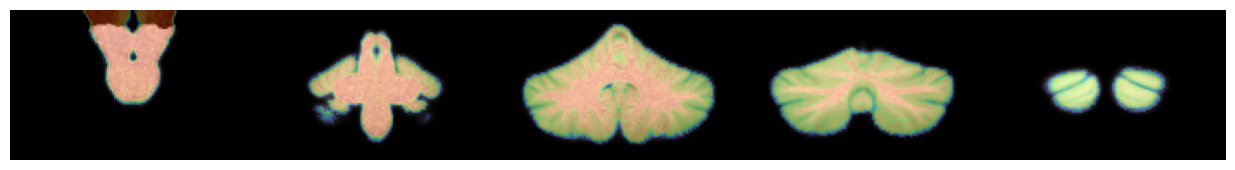

In [4]:
import ants
w_anat_img = ants.image_read(mytx['normalized_file'])
template_img = ants.image_read('/Users/wangyaping/Documents/GitHub/SUITPy/SUITPy/templates/tpl-SUIT_T1w.nii.gz')
ants.plot(template_img, overlay=w_anat_img, axis=1, nslices=5, overlay_alpha=0.4)

## Different Template space
Describe the different cerebellar-only template space
Show and explain how to use the ``space`` option 

By default, the image is normalized to the SUIT cerebellar template.
If you want to use a different target space, simply specify the ``space`` parameter: `SUIT`, `MNI152NLin6AsymC` / 'MNI', `MNI152NLin2009cSymC` / 'MNISym'.
If you wish to use a custom cerebellum-only template that is not included in these options, you can provide a file directly using the ``template_file`` parameter: Optional path to a custom template file

In [8]:
# This function normalizes a source image to the MNI152NLin2009cSymC space using a provided cerebellum mask.
mytx = normalize(source_file = 'anatomical_sess-01.nii',
                 mask_file = 'anatomical_sess-01_cerebellum_dseg.nii.gz',
                 space = 'MNISym',
                 verbose = True)

Registering to template of /Applications/anaconda3/envs/SUIT2/lib/python3.10/site-packages/SUITPy/templates/tpl-MNI152NLin2009cSymC_T1w.nii.gz
antsRegistration --dimensionality 3 -r [0x15a5c5d88,0x15a5c67c8,1] --output [/Users/wangyaping/Documents/GitHub/SUITPy/docs/source/tutorials/anatomical_sess-01_xfm-MNISym_,0x15a5c6c48,0x15a5c7188] --transform Rigid[0.1] --metric MI[0x15a5c5d88,0x15a5c67c8,1,32,Regular,0.25] --convergence [1000x500x250x100,1e-6,10] --shrink-factors 8x4x2x1 --smoothing-sigmas 3x2x1x0vox --transform Affine[0.1] --metric MI[0x15a5c5d88,0x15a5c67c8,1,32,Regular,0.25] --convergence [1000x500x250x100,1e-6,10] --shrink-factors 8x4x2x1 --smoothing-sigmas 3x2x1x0vox --transform SyN[0.2,3,0] --metric CC[0x15a5c5d88,0x15a5c67c8,1,2] --convergence [100x70x50x20,1e-6,10] --shrink-factors 8x4x2x1 --smoothing-sigmas 3x2x1x0vox -x [NA,NA] --float 1 --write-composite-transform 1 -v 1
All_Command_lines_OK
Using single precision for computations.
The composite transform comprises t

Exception: Transform /Users/wangyaping/Documents/GitHub/SUITPy/docs/source/tutorials/anatomical_sess-01_xfm-MNISym_1Warp.nii.gz does not exist

In [ ]:
mytx

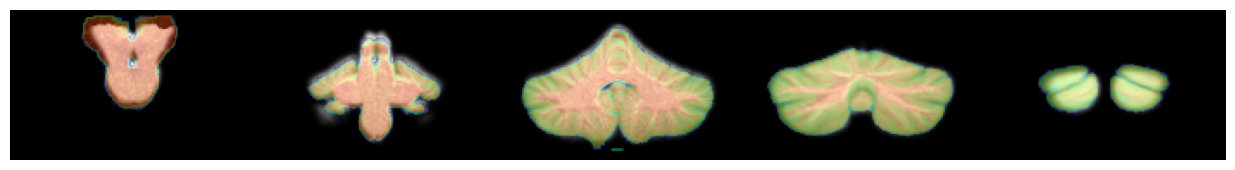

In [ ]:
# The normalized image in MNI152NLin2009cSymC space, not SUIT space
import ants
w_anat_img = ants.image_read(mytx['normalized_file'])
template_img = ants.image_read('/Users/wangyaping/Documents/GitHub/SUITPy/SUITPy/templates//tpl-SUIT_T1w.nii.gz')
ants.plot(template_img, overlay=w_anat_img, axis=1, nslices=5, overlay_alpha=0.4)

In [ ]:
# This function normalizes a source image to the MNI152NLin2009cSymC space using a provided cerebellum mask.
mytx = normalize(source_file = 'anatomical_sess-01.nii',
                 mask_file = 'anatomical_sess-01_cerebellum_dseg.nii.gz',
                 space = 'MNI152NLin6AsymC',
                 verbose = False)

## Transforms between different template spaces 
Show how to transform data from SUIT to MNI or MNISym space 